PREGUNTAS A RESPONDER:
-CUALES SON LAS VARIABLES QUE DETERMINAN QUE UN EQUIPO SEA MEJOR QUE OTRO EN UNA TEMPORADA?
-Clustering: Agrupar equipos según su eficiencia (goles/tiros, goles/posesión, etc.) para ver qué grupos de equipos son más efectivos.(Identificacion patrones de eficacia). Podriamos resolver valores atipicos en base a comapraciones finales
-Clustering: Equipos con estilos similares (segun variables)
-Clustering ¿Qué jugadores o equipos generan más acciones clave (pases, tiros, recuperaciones) en los partidos? - jugadores mas influyentes segun registros, que equipos dependen de mas acciones individuales
-Partidos mas taquilleros (se puede??)
-¿Qué equipos recibieron más presión en campo rival?
-¿En qué minutos se concentran más goles en la liga/torneo?
-EXPLORATORIO/OUTLIERS: ¿Qué jugadores generan valores atípicos en volumen de acciones clave (ej. un mediocampista con más recuperaciones que el promedio de su liga)?

-PREDECIR EQUIPO CAMPEON 2025/2026

UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (ANALISIS MÁS CLASICO)
UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (MÁS GRANULAR (ANALISIS ESPACIAL Y DINAMICO (TRACKING)))

In [3]:
#libraries
#pip install statsbombpy - libreria de Hudl
#pip install mplsoccer - traza de canchas, graficos (radar, pizza, cambios en el tiempo, etc), flechas, mapas de calor, entre otros.
#URL MPLSOCCER DOCS: https://mplsoccer.readthedocs.io/en/latest/
#pakcs
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns

In [3]:
#aspectos principales de la libreria statsbombs
#datasets principales: competitios, matches, events, lineups, frames
#ver la doc de cada funcion -> help(sb.competitions)
dir(sb)

['DEFAULT_CREDS',
 'MAX_CONCURRENCY',
 'Pool',
 'Union',
 '_360_frames',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'api_client',
 'competition_events',
 'competition_frames',
 'competitions',
 'events',
 'filter_and_group_events',
 'frames',
 'lineups',
 'matches',
 'merge_events_and_frames',
 'partial',
 'pd',
 'player_match_stats',
 'player_season_stats',
 'public',
 'reduce_events',
 'team_match_stats',
 'team_season_stats']

In [ ]:
#LaLiga => competition_id=11; TENEMOS 17 TEMPORADAS
competitions = sb.competitions();
la_liga = competitions[competitions["competition_id"]==11];
la_liga.head(1)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386


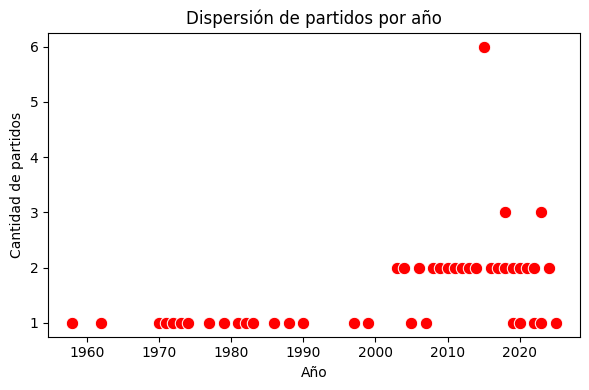

In [29]:
#cuenteo de partidos por temp
partidos_x_temp = competitions.groupby('season_name').size().reset_index(name='cantidad_partidos')
#Prueba grafica (x,y) donde se visualicen cant de partidos por año
partidos_x_temp['season_year'] = partidos_x_temp['season_name'].str[:4].astype(int)

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='season_year', 
    y='cantidad_partidos', 
    data=partidos_x_temp,
    s=80, color='red'
)
plt.xlabel('Año')
plt.ylabel('Cantidad de partidos')
plt.title('Dispersión de partidos por año')
plt.tight_layout()
plt.show()


In [47]:
#variables - matches
matches = sb.matches(competition_id=11,season_id=90);
matches.columns

Index(['match_id', 'match_date', 'kick_off', 'competition', 'season',
       'home_team', 'away_team', 'home_score', 'away_score', 'match_status',
       'match_status_360', 'last_updated', 'last_updated_360', 'match_week',
       'competition_stage', 'stadium', 'referee', 'home_managers',
       'away_managers', 'data_version', 'shot_fidelity_version',
       'xy_fidelity_version'],
      dtype='object')

In [ ]:
# Cargar los eventos del partido
events = sb.events(match_id=3754037)  # Cambia el match_id por el que te interese
events.columns;

Index(['ball_receipt_outcome', 'ball_recovery_offensive',
       'ball_recovery_recovery_failure', 'carry_end_location',
       'clearance_aerial_won', 'clearance_body_part', 'clearance_head',
       'clearance_left_foot', 'clearance_right_foot', 'counterpress',
       'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome',
       'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive',
       'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive',
       'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome',
       'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id',
       'index', 'interception_outcome', 'location', 'match_id', 'minute',
       'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won',
       'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross',
       'pass_cut_back', 'pass_end_location', 'pass_goal_assist', 'pass_height',
   

In [46]:
events = sb.events(match_id=3754037)

# columnas
cols = events.columns.tolist()
print(len(cols), "columnas")
print(cols[:40])  # muestra las primeras 40

# tipos de evento disponibles
print(events['type'].dropna().unique())

# vista rápida de tipos de datos y faltantes
events.info()
events.isna().mean().sort_values(ascending=False).head(20)  # % de nulos por columna

88 columnas
['ball_receipt_outcome', 'ball_recovery_offensive', 'ball_recovery_recovery_failure', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_offensive', 'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'interception_outcome', 'location', 'match_id', 'minute', 'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id']
['Starting XI' 'Half Start' 'Pass' 'Ball Receipt*' 'Carry' 'Pressure'
 'Ball Recovery' 'Clearance' 'Dispossessed' 'Duel' 'Foul Committed'
 'Foul Won' 'Miscontrol' 'Interception' 'Dribbled Past'

foul_committed_type         0.999744
foul_committed_card         0.999744
foul_committed_offensive    0.999744
pass_no_touch               0.999744
pass_straight               0.999744
shot_aerial_won             0.999744
dribble_nutmeg              0.999489
ball_recovery_offensive     0.999489
pass_inswinging             0.999489
tactics                     0.999489
pass_cut_back               0.999489
pass_outswinging            0.999489
pass_goal_assist            0.999233
foul_won_defensive          0.999233
foul_won_advantage          0.999233
foul_committed_advantage    0.999233
miscontrol_aerial_won       0.998978
pass_technique              0.998722
goalkeeper_body_part        0.998467
dribble_overrun             0.998467
dtype: float64

In [49]:
#variables frames - datos de tracking (seguimiento) - incluye coordenadas x/y
frames = sb.frames(match_id=3895074)
frames.columns

Index(['id', 'visible_area', 'match_id', 'teammate', 'actor', 'keeper',
       'location'],
      dtype='object')